# Hough-Transformation

In [1]:
# Update pip
#!python -m pip install -U pip

In [2]:
# Install scikit-image
#!python -m pip install -U scikit-image

In [3]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as pl
import ipywidgets as iw
import skimage.transform as st

## Bild einlesen

(256, 256, 3)
(256, 256)


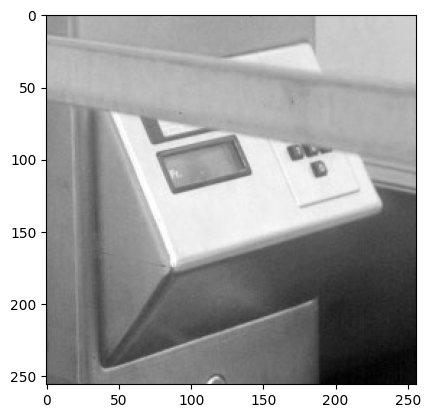

In [4]:
img_rgb = cv.imread ('Images/geraden.jpg')
print (img_rgb.shape)
img  = cv.cvtColor (img_rgb, cv.COLOR_BGR2GRAY)
print (img.shape)
pl.imshow (img, cmap = 'gray')

## Kanten erkennen (Canny)

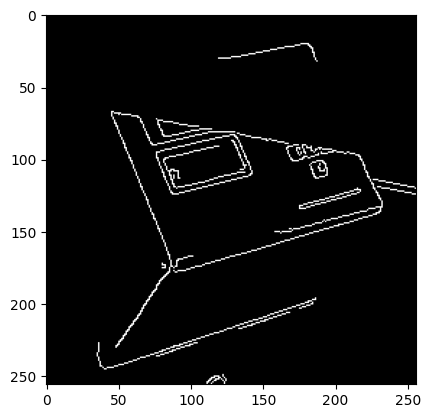

In [5]:
edg = cv.Canny (img, 100, 200, apertureSize = 3, L2gradient = True)
pl.imshow (edg, cmap = 'gray')

## Hough-Transformation für Geraden in OpenCV

### Berechnung

In [6]:
lines = cv.HoughLines (edg, 1, np.pi / 180, 90)
n = lines.shape [0]
print (n)

5


### Ergebnisse zeichnen

(256, 256)


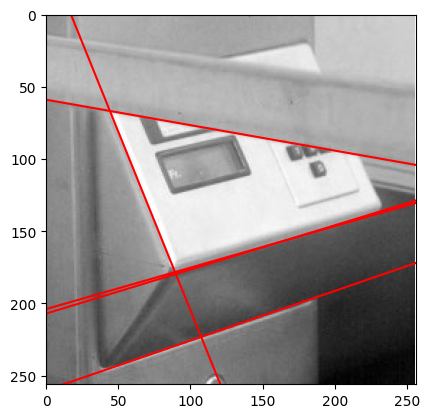

In [7]:
pl.imshow (img, cmap = 'gray')
print(img.shape)
dy, dx = img.shape
pl.xlim ([0, dx])
pl.ylim ([dy, 0])

d = np.sqrt (dx ** 2 + dy ** 2)

for i in np.arange (n):
    for rho, phi in lines [i]:
        c = np.cos (phi)
        s = np.sin (phi)
        p0 = rho * np.array ([[c], [s]])
        u = np.array ([[-s], [c]])
        p1 = p0 - d * u
        p2 = p0 + d * u
        pl.plot ((p1 [0], p2 [0]), (p1 [1], p2 [1]), 'r')

## Hough-Transformation für Geraden in scikit-image

105


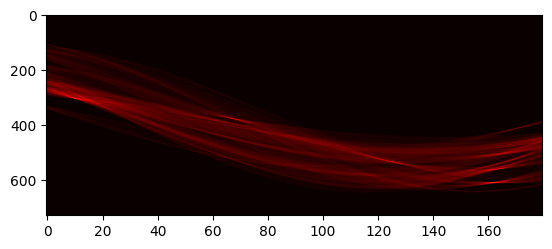

In [8]:
accu1, angles1, distances1 = st.hough_line (edg)
print (np.max (accu1))
pl.imshow (accu1, cmap = 'hot', aspect = 0.1)

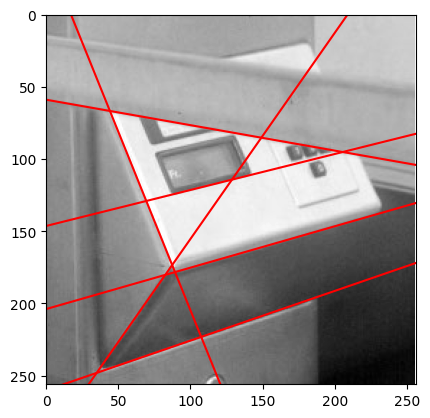

In [9]:
accu2, angles2, distances2 = st.hough_line_peaks (accu1, angles1, distances1, threshold = 50)
pl.imshow (img, cmap = 'gray')

h, w = img.shape
pl.xlim ([0, w])
pl.ylim ([h, 0])

for rho, phi in zip (distances2, angles2):
    c = np.cos (phi)
    s = np.sin (phi)
    p0 = rho * np.array ([[c], [s]])
    u = np.array ([[-s], [c]])
    p1 = p0 - d * u
    p2 = p0 + d * u
    pl.plot ((p1 [0], p2 [0]), (p1 [1], p2 [1]), 'r')

## Quellen

https://docs.opencv.org/3.4/dd/d1a/group__imgproc__feature.html

https://scikit-image.org/docs/dev/api/skimage.transform.html?highlight=hough#skimage.transform.hough_line